# 1 Business Understanding
The goal of this notebook is to explore an online retail transactional dataset in order to:

* **Understand sales performance**
* **Identify customer behavior patterns**
* **Analyze product-level performance**
* **Detect operational issues** (returns, cancellations)
* **Generate actionable business insights**

---

## 2️ Retail Concepts to Master in This Notebook
This notebook will not only analyze data — it will also build strong retail domain knowledge.

###  Order vs Line Item
* Understand difference between invoice/order level and product-level rows
* Calculate metrics correctly at the right level

###  SKU Granularity
* Analyze performance at:
    * **SKU level** (product-level analysis)
    * **Order level**
    * **Customer level**
* Understand impact of granularity on metrics

###  GMV vs Revenue
* **Calculate:**
    * **GMV (Gross Merchandise Value)** = total sales before returns
    * **Net Revenue** = after returns & cancellations
* Compare both over time

###  Returns vs Cancellations
* **Identify:**
    * Canceled invoices
    * Negative quantities (returns)
* Understand operational and financial impact

###  Time Aggregation
* **Analyze:**
    * Daily sales
    * Weekly trends
    * Monthly growth
* Detect seasonality patterns

###  Repeat Customers
* **Identify:**
    * New vs returning customers
* **Measure:**
    * Repeat purchase rate
    * Customer frequency

###  Return Rate
* **Compute:**
    * Return rate per SKU
    * Return rate overall
* Identify problematic products

###  Data Cleaning with Business Rules
Apply retail-specific cleaning logic:
* Remove canceled invoices
* Handle negative quantities
* Remove invalid prices
* Filter out test SKUs or anomalies

###  Customer & Product Segmentation
* **Segment by:**
    * High-value customers
    * High-return customers
    * Top-performing SKUs
    * Low-performing SKUs

###  Retail Storytelling
Translate data into business insights:
* What drives revenue?
* Which products hurt profit?
* Who are our best customers?
* When do we sell the most?
* Where are operational inefficiencies?

---

##  Final Learning Objective
By the end of this notebook, I should be able to:
1.  **Think like a Retail Data Analyst**
2.  **Speak retail KPIs confidently** (GMV, SKU, return rate, repeat rate)
3.  **Transform raw transactional data into business decisions**
4.  **Tell a clear data-driven retail story**

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(f"D:\\retail-projects\\online-retail-analysis\\data\\raw\\online_retail_II.csv")
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


###  Order vs Line Item

* **What is an Order?**
    An Order is a single purchase transaction made by a customer (often identified by a unique `Invoice` or `Order ID`).
    
* **What is a Line Item?**
    A Line Item is a single product entry inside an order. If a customer buys 3 apples and 2 oranges, that is one **Order** with two **Line Items**.

> **Pro Tip:** "An order represents a complete transaction by a customer, while a line item represents an individual product within that order. Most retail datasets are structured at the line-item level, so aggregating correctly to the order level is critical for calculating metrics like **AOV (Average Order Value)**, order frequency, and customer value."

In [5]:
# Count Orders
total_orders = df["Invoice"].nunique()
print(total_orders)

53628


In [6]:
# Count Line Item
total_line_items = len(df)
print(total_line_items)

1067371


In [7]:
# Calculate Order Value
df["line_total"] = df["Quantity"] * df["Price"]
order_value = df.groupby("Invoice")["line_total"].sum()
print(order_value)

Invoice
489434        505.30
489435        145.80
489436        630.33
489437        310.75
489438       2286.24
             ...    
C581484   -168469.60
C581490       -32.53
C581499      -224.69
C581568       -54.75
C581569        -7.50
Name: line_total, Length: 53628, dtype: float64


In [8]:
#Average Items Per Order
items_per_order = df.groupby("Invoice").size().mean()
print(items_per_order)

19.90324084433505


###  SKU and Data Granularity

* **What is a SKU?**
    **SKU = Stock Keeping Unit**. It is the unique identifier for a specific product variation. A SKU represents the most specific version of a product, including attributes like color, size, or material.
    * *Example:* It’s not just a "T-shirt"—it’s a **"Black T-shirt, Size M, Cotton"**.

* **What Does “Granularity” Mean?**
    **Granularity = The level of detail in your data.**
    * **High Granularity:** Analyzing data at the SKU level (the most detailed).
    * **Low Granularity:** Analyzing data at the Category level (e.g., "Apparel") or Brand level.

> **Key Insight:** "SKU granularity refers to analyzing retail data at the individual product-variation level. It enables precise inventory optimization, pricing strategies, and identification of top- and low-performing items. Without SKU-level analysis, businesses risk making inaccurate stocking and promotion decisions."

In [9]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,line_total
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


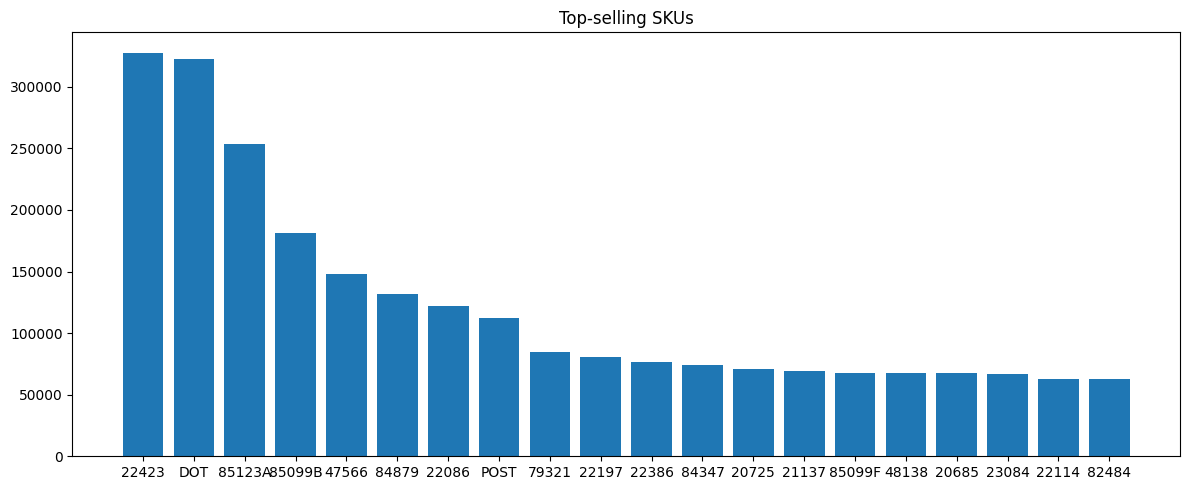

In [10]:
# Revenue Per SKU
sku_revenue = df.groupby("StockCode")["line_total"].sum().sort_values(ascending=False)

# Plot Top 20 SKUs
top_20 = sku_revenue.head(20)
plt.figure(figsize=(12,5))
plt.title("Top-selling SKUs")
plt.bar(x=top_20.index, height=top_20)
plt.tight_layout()
plt.show()

    The revenue distribution among the top 20 SKUs shows strong concentration in the first few products. The top two SKUs significantly outperform the rest, followed by a noticeable drop in revenue contribution.

    After the top 5 SKUs, revenue begins to level off, indicating a classic long-tail distribution where a small number of products drive a large portion of total sales.

> This pattern suggests that the business heavily relies on a limited number of high-performing “hero” SKUs. These products are critical to overall revenue performance and should be closely monitored for stock availability and pricing strategy.

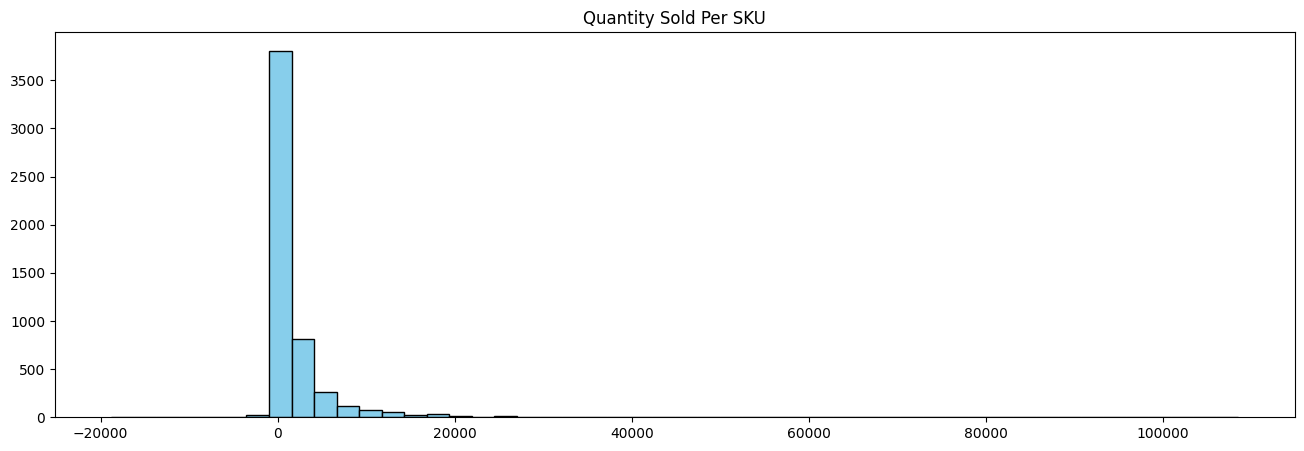

In [11]:
# Quantity Sold Per SKU
sku_quantity = df.groupby("StockCode")["Quantity"].sum()

# plot Quantity Sold Per SKU
plt.figure(figsize=(16,5))
plt.title("Quantity Sold Per SKU")
plt.hist(sku_quantity, bins=50, color='skyblue', edgecolor='black')
plt.show()

        Most products sell only a small number of units, while a small group of SKUs are fast-moving and drive most of the sales volume.

In [12]:
sku_quantity.sort_values(ascending=False).head(20)

StockCode
84077     108545
85123A     96066
85099B     95739
21212      95450
84879      80705
22197      79363
17003      70700
21977      56575
84991      54366
22492      45384
15036      42556
21213      40644
22616      40295
84755      40110
20725      40011
22178      39738
22386      39358
21232      38033
84568      37709
84946      37611
Name: Quantity, dtype: int64

                A few popular products are doing most of the work. Some items, like 85123A and 85099B, are "Superstars"—they sell in huge numbers and bring in a lot of money.

                However, some other items sell in massive quantities but don’t make much money. This usually means they are very cheap items sold at a low profit to keep volume high.

In [13]:
# Average Price Per SKU
sku_avg_price = df.groupby("StockCode")["Price"].mean()

In [15]:
low_selling = sku_quantity[sku_quantity < 10]
dead_pct = len(low_selling) / len(sku_quantity)
print(f"Percentage of low-selling SKUs: {dead_pct:.2%}")

Percentage of low-selling SKUs: 17.42%
